<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multivariate" data-toc-modified-id="Multivariate-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multivariate</a></span></li><li><span><a href="#Univariate" data-toc-modified-id="Univariate-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Univariate</a></span></li></ul></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
wdf = pd.read_csv('waterlevel_54375010.csv') 
rdf = pd.read_csv('rainfall_525510.csv')

print(wdf)
print(rdf)

                       Timestamp  Value
0      2023-01-01 00:00:00+00:00  0.569
1      2023-01-01 00:15:00+00:00  0.566
2      2023-01-01 00:30:00+00:00  0.569
3      2023-01-01 00:45:00+00:00  0.566
4      2023-01-01 01:00:00+00:00  0.566
...                          ...    ...
70171  2024-12-31 22:45:00+00:00  0.485
70172  2024-12-31 23:00:00+00:00  0.481
70173  2024-12-31 23:15:00+00:00  0.477
70174  2024-12-31 23:30:00+00:00  0.472
70175  2024-12-31 23:45:00+00:00  0.467

[70176 rows x 2 columns]
                       Timestamp  Value
0      2023-01-01 00:00:00+00:00    0.2
1      2023-01-01 00:15:00+00:00    0.0
2      2023-01-01 00:30:00+00:00    0.2
3      2023-01-01 00:45:00+00:00    0.0
4      2023-01-01 01:00:00+00:00    0.2
...                          ...    ...
70129  2024-12-31 22:45:00+00:00    0.0
70130  2024-12-31 23:00:00+00:00    0.0
70131  2024-12-31 23:15:00+00:00    0.0
70132  2024-12-31 23:30:00+00:00    0.0
70133  2024-12-31 23:45:00+00:00    0.0

[70134 rows x

In [3]:
wdf['Timestamp'] = pd.to_datetime(wdf['Timestamp']).dt.tz_localize(None)
rdf['Timestamp'] = pd.to_datetime(rdf['Timestamp']).dt.tz_localize(None)

print(wdf)
print(rdf)

                Timestamp  Value
0     2023-01-01 00:00:00  0.569
1     2023-01-01 00:15:00  0.566
2     2023-01-01 00:30:00  0.569
3     2023-01-01 00:45:00  0.566
4     2023-01-01 01:00:00  0.566
...                   ...    ...
70171 2024-12-31 22:45:00  0.485
70172 2024-12-31 23:00:00  0.481
70173 2024-12-31 23:15:00  0.477
70174 2024-12-31 23:30:00  0.472
70175 2024-12-31 23:45:00  0.467

[70176 rows x 2 columns]
                Timestamp  Value
0     2023-01-01 00:00:00    0.2
1     2023-01-01 00:15:00    0.0
2     2023-01-01 00:30:00    0.2
3     2023-01-01 00:45:00    0.0
4     2023-01-01 01:00:00    0.2
...                   ...    ...
70129 2024-12-31 22:45:00    0.0
70130 2024-12-31 23:00:00    0.0
70131 2024-12-31 23:15:00    0.0
70132 2024-12-31 23:30:00    0.0
70133 2024-12-31 23:45:00    0.0

[70134 rows x 2 columns]


In [4]:
# Data count
print(f"Initial Water Level data points: {len(wdf)}")
print(f"Initial Rainfall data points: {len(rdf)}")

Initial Water Level data points: 70176
Initial Rainfall data points: 70134


In [5]:
# Check for missing values
print("Water level missing values:\n", wdf.isnull().sum())
print("\nRainfall missing values:\n", rdf.isnull().sum())

Water level missing values:
 Timestamp    0
Value        0
dtype: int64

Rainfall missing values:
 Timestamp    0
Value        0
dtype: int64


In [6]:
# Check for duplicates
wdf = wdf.drop_duplicates(subset=['Timestamp']).dropna()
rdf = rdf.drop_duplicates(subset=['Timestamp']).dropna()

print(f"Water Level after cleaning: {len(wdf)}")
print(f"Rainfall after cleaning: {len(rdf)}")

Water Level after cleaning: 70176
Rainfall after cleaning: 70134


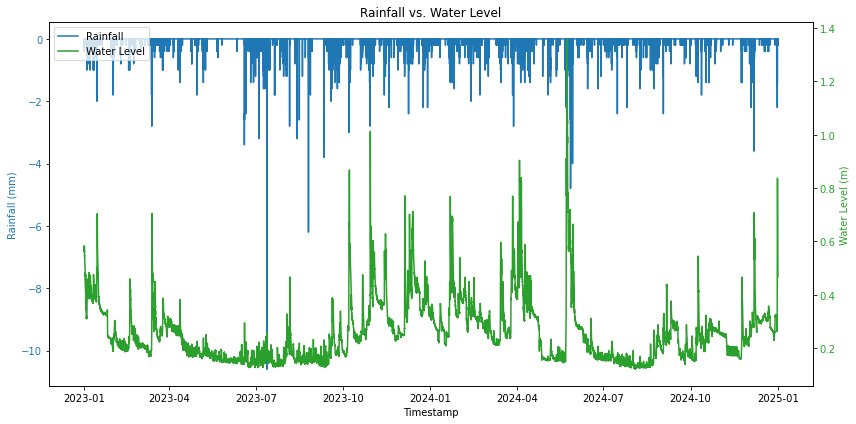

In [7]:
# Visualisation
plt.figure(figsize=(12, 6))

# Create primary axis
ax1 = plt.gca()
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Rainfall (mm)', color=color)
ax1.plot(rdf['Timestamp'], -rdf['Value'], color=color, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Water Level (m)', color=color)
ax2.plot(wdf['Timestamp'], wdf['Value'], color=color, label='Water Level')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Rainfall vs. Water Level')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Merge datasets
merged = pd.merge_asof(wdf.sort_values('Timestamp'), 
                      rdf.sort_values('Timestamp'), 
                      on='Timestamp',
                      direction='nearest',
                      tolerance=pd.Timedelta('15min'))
merged = merged.rename(columns={'Value_x': 'WaterLevel', 'Value_y': 'Rainfall'})
print(merged)

                Timestamp  WaterLevel  Rainfall
0     2023-01-01 00:00:00       0.569       0.2
1     2023-01-01 00:15:00       0.566       0.0
2     2023-01-01 00:30:00       0.569       0.2
3     2023-01-01 00:45:00       0.566       0.0
4     2023-01-01 01:00:00       0.566       0.2
...                   ...         ...       ...
70171 2024-12-31 22:45:00       0.485       0.0
70172 2024-12-31 23:00:00       0.481       0.0
70173 2024-12-31 23:15:00       0.477       0.0
70174 2024-12-31 23:30:00       0.472       0.0
70175 2024-12-31 23:45:00       0.467       0.0

[70176 rows x 3 columns]


In [9]:
merged.isnull().sum()

Timestamp      0
WaterLevel     0
Rainfall      26
dtype: int64

In [10]:
null_rainfall = merged[merged['Rainfall'].isnull()]
print(f"Rows with null Rainfall ({len(null_rainfall)}):\n", null_rainfall)

Rows with null Rainfall (26):
                 Timestamp  WaterLevel  Rainfall
997   2023-01-11 09:15:00       0.444       NaN
998   2023-01-11 09:30:00       0.445       NaN
999   2023-01-11 09:45:00       0.441       NaN
1000  2023-01-11 10:00:00       0.442       NaN
1001  2023-01-11 10:15:00       0.438       NaN
1002  2023-01-11 10:30:00       0.440       NaN
1003  2023-01-11 10:45:00       0.441       NaN
3781  2023-02-09 09:15:00       0.221       NaN
3782  2023-02-09 09:30:00       0.222       NaN
8973  2023-04-04 11:15:00       0.282       NaN
11653 2023-05-02 09:15:00       0.199       NaN
11654 2023-05-02 09:30:00       0.200       NaN
11655 2023-05-02 09:45:00       0.199       NaN
14925 2023-06-05 11:15:00       0.158       NaN
14926 2023-06-05 11:30:00       0.158       NaN
14927 2023-06-05 11:45:00       0.158       NaN
14928 2023-06-05 12:00:00       0.158       NaN
17613 2023-07-03 11:15:00       0.130       NaN
17614 2023-07-03 11:30:00       0.130       NaN
17615 202

In [11]:
merged['Rainfall_original'] = merged['Rainfall']

# Step 2: Apply forward fill
merged['Rainfall'] = merged['Rainfall'].fillna(method='ffill')

# Step 3: Identify where forward fill was applied
ffilled = merged[
    merged['Rainfall_original'].isnull() & merged['Rainfall'].notnull()
]

# Step 4: Print the rows that were filled
print(f"Forward-filled rows ({len(ffilled)}):\n", ffilled[['Timestamp', 'Rainfall_original', 'Rainfall']])

Forward-filled rows (26):
                 Timestamp  Rainfall_original  Rainfall
997   2023-01-11 09:15:00                NaN       0.0
998   2023-01-11 09:30:00                NaN       0.0
999   2023-01-11 09:45:00                NaN       0.0
1000  2023-01-11 10:00:00                NaN       0.0
1001  2023-01-11 10:15:00                NaN       0.0
1002  2023-01-11 10:30:00                NaN       0.0
1003  2023-01-11 10:45:00                NaN       0.0
3781  2023-02-09 09:15:00                NaN       0.0
3782  2023-02-09 09:30:00                NaN       0.0
8973  2023-04-04 11:15:00                NaN       0.0
11653 2023-05-02 09:15:00                NaN       0.0
11654 2023-05-02 09:30:00                NaN       0.0
11655 2023-05-02 09:45:00                NaN       0.0
14925 2023-06-05 11:15:00                NaN       0.0
14926 2023-06-05 11:30:00                NaN       0.0
14927 2023-06-05 11:45:00                NaN       0.0
14928 2023-06-05 12:00:00             

In [12]:
print(f"Water Level after cleaning: {len(merged['Rainfall'])}")
print(f"Water Level after cleaning: {len(merged['WaterLevel'])}")

Water Level after cleaning: 70176
Water Level after cleaning: 70176


In [13]:
# forward fill (Carry Last Observation)
merged['Rainfall'] = merged['Rainfall'].fillna(method='ffill')

merged.isnull().sum()

Timestamp             0
WaterLevel            0
Rainfall              0
Rainfall_original    26
dtype: int64

In [14]:
# Correlation
corr, p_value = pearsonr(merged['WaterLevel'], merged['Rainfall'])
print(f"Immediate correlation: {corr:.3f} (p-value: {p_value:.3f})")

if abs(corr) < 0.3:
    print("Low correlation - suggesting time lag effects")

Immediate correlation: 0.168 (p-value: 0.000)
Low correlation - suggesting time lag effects


There is a weak positive correlation (0.168) between rainfall and water level at the exact same time point (lag=0) <br>
The p-value of 0.000 (typically meaning p < 0.001) suggests this correlation is statistically significant, meaning it's unlikely due to random chance.<br>
<br>
No shift (lag = 0): Rainfall and water level at the same timestamp → Weak correlation (0.168 in your case). <br>
With shift (lag > 0): Rainfall at time t vs. water level at t + lag → Likely stronger correlation.

In [15]:
x = merged['Rainfall'].values
y = merged['WaterLevel'].values

# Normalise
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

# Full cross-correlation
corrs = np.correlate(y, x, mode='full')
lags = np.arange(-len(x)+1, len(x))

# Find lag with maximum correlation
best_lag = lags[np.argmax(corrs)]
print(f"Max correlation at lag = {best_lag} samples")

# Convert lag to time
time_step = pd.to_timedelta('15min')
time_lag = best_lag * time_step
print(f"Time lag = {time_lag}")

Max correlation at lag = 29 samples
Time lag = 0 days 07:15:00


1 sample = 15 minutes <br>
29 samples = 29 × 15 minutes = 435 minutes = 7 hours 15 minutes

The cross‑correlation analysis between rainfall and water level shows a maximum correlation at a lag of 29 samples (approximately 7 hours 15 minutes). This indicates that changes in rainfall are most strongly associated with changes in water level about 7 hours 15 minutes later. This lag likely reflects the catchment’s hydrological response time, including runoff and flow routing processes. This delay accounts for runoff travel time? Soil infiltration?

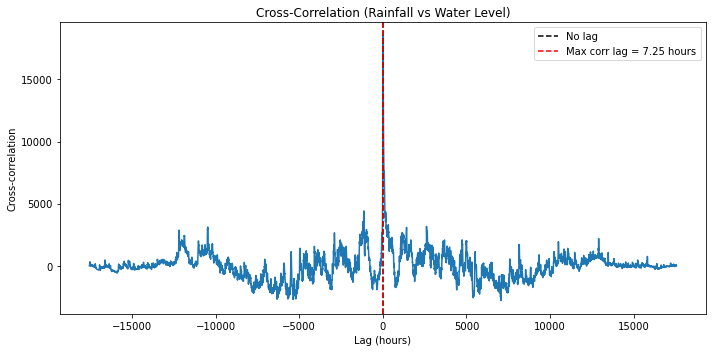

In [16]:
lags_hours = lags * (15/60)  # 15 minutes per sample
plt.figure(figsize=(10,5))
plt.plot(lags_hours, corrs)
plt.axvline(x=0, color='k', linestyle='--', label='No lag')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', 
            label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation')
plt.title('Cross-Correlation (Rainfall vs Water Level)')
plt.legend()
plt.tight_layout()
plt.show()

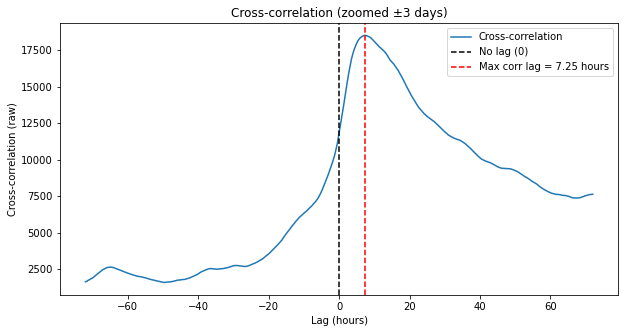

In [17]:
# Suppose you only care about ±3 days = 3*24 hours
max_hours = 3*24
mask = (lags_hours >= -max_hours) & (lags_hours <= max_hours)

plt.figure(figsize=(10,5))
plt.plot(lags_hours[mask], corrs[mask], label='Cross-correlation')
plt.axvline(x=0, color='k', linestyle='--', label='No lag (0)')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation (raw)')
plt.title('Cross-correlation (zoomed ±3 days)')
plt.legend(loc='best')
plt.show()

In [18]:
# Split train / validation / test BEFORE scaling
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

n = len(merged)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_raw = merged[['Rainfall','WaterLevel']].iloc[:train_end]
val_raw   = merged[['Rainfall','WaterLevel']].iloc[train_end:val_end]
test_raw  = merged[['Rainfall','WaterLevel']].iloc[val_end:]

# Multivariate
Input(X): rainfall + water level <br>
Output(Y): water level

In [19]:
# Normalisation
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

In [20]:
columns = ['Rainfall', 'WaterLevel']
train_df = pd.DataFrame(train_scaled, columns=columns)
validation_df = pd.DataFrame(val_scaled, columns=columns)
test_df = pd.DataFrame(test_scaled, columns=columns)

# Calculate statistical properties for each dataset
stats_train = train_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_validation = validation_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_test = test_df.describe().loc[['mean', 'std', 'min', 'max']]

# Compare the statistics
print("Training Data Stats:\n", stats_train, "\n")
print("Validation Data Stats:\n", stats_validation, "\n")
print("Testing Data Stats:\n", stats_test, "\n")

Training Data Stats:
       Rainfall  WaterLevel
mean  0.002847    0.116935
std   0.014930    0.100900
min   0.000000    0.000000
max   1.000000    1.000000 

Validation Data Stats:
       Rainfall  WaterLevel
mean  0.001913    0.060377
std   0.012234    0.069749
min   0.000000   -0.004870
max   0.452830    0.481331 

Testing Data Stats:
       Rainfall  WaterLevel
mean  0.001653    0.100007
std   0.009799    0.058306
min   0.000000    0.010552
max   0.339623    0.576299 



In [21]:
# Create sequences for LSTM
def create_sequences(data, past_steps=32, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - past_steps - forecast_horizon + 1):
        X.append(data[i : i + past_steps, :])                                      # past [Rainfall, WaterLevel]
        y.append(data[i + past_steps : i + past_steps + forecast_horizon, 1][-1])  # future WaterLevel
    return np.array(X), np.array(y)

past_steps = 32          # 32 × 15 min = 480 min = 8 hours
forecast_horizon = 1     # predict next step
X_train, y_train = create_sequences(train_scaled, past_steps, forecast_horizon)
X_val,   y_val   = create_sequences(val_scaled, past_steps, forecast_horizon)
X_test,  y_test  = create_sequences(test_scaled, past_steps, forecast_horizon)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (49091, 32, 2) (49091,)
Val:   (10494, 32, 2) (10494,)
Test:  (10495, 32, 2) (10495,)


In [22]:
# Build LSTM model
n_features = X_train.shape[2]

model = Sequential()
model.add(LSTM(64, input_shape=(past_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
768/768 [==============================] - 39s 39ms/step - loss: 1.7586e-04 - val_loss: 4.8025e-05
Epoch 2/200
768/768 [==============================] - 31s 40ms/step - loss: 3.1975e-05 - val_loss: 3.7598e-05
Epoch 3/200
768/768 [==============================] - 32s 41ms/step - loss: 2.2377e-05 - val_loss: 2.3835e-05
Epoch 4/200
768/768 [==============================] - 37s 49ms/step - loss: 1.7388e-05 - val_loss: 1.8548e-05
Epoch 5/200
768/768 [==============================] - 37s 48ms/step - loss: 1.2587e-05 - val_loss: 2.4934e-05
Epoch 7/200
768/768 [==============================] - 38s 50ms/step - loss: 1.1310e-05 - val_loss: 1.2974e-05
Epoch 8/200
768/768 [==============================] - 42s 54ms/step - loss: 1.0078e-05 - val_loss: 1.3509e-05
Epoch 9/200
768/768 [==============================] - 33s 43ms/step - loss: 9.5322e-06 - val_loss: 1.0289e-05
Epoch 10/200
768/768 [==============================] - 45s 59ms/step - loss: 9.2483e-06 - val_loss: 9.5877e-06


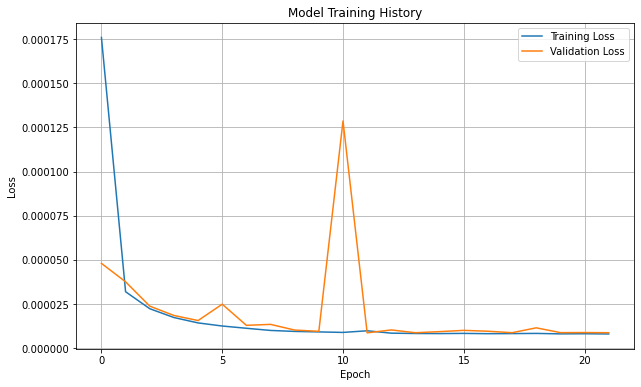

In [23]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform predictions
temp_pred = np.zeros((len(y_pred_scaled), 2))
temp_pred[:, 1] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(temp_pred)[:, 1]

temp_true = np.zeros((len(y_test), 2))
temp_true[:, 1] = y_test
y_true = scaler.inverse_transform(temp_true)[:, 1]

328/328 [==============================] - 9s 13ms/step


In [25]:
def plot_predictions_with_error(true_data, predicted_data, rainfall_data, title):
    plt.figure(figsize=(14, 6))
    
    true_data_flatten = true_data.flatten()
    predicted_data_flatten = predicted_data.flatten()
    rainfall_flatten = rainfall_data.flatten()
    
    error = true_data_flatten - predicted_data_flatten
    residuals_std = np.std(error)
    
    # --- Left subplot: water level + inverted rainfall ---
    ax1 = plt.subplot(1, 2, 1)
    
    # Plot true and predicted water level on primary y-axis
    line1, = ax1.plot(true_data_flatten, label='True Water Level', color='#1f77b4', linewidth=2)
    line2, = ax1.plot(predicted_data_flatten, label='Predicted Water Level', color='#ff7f0e', alpha=0.7, linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Water Level')
    ax1.set_title(title)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Create secondary y-axis for rainfall
    ax2 = ax1.twinx()
    line3, = ax2.plot(-rainfall_flatten, label='Inverted Rainfall', color='tab:blue', alpha=0.5)
    ax2.set_ylabel('Rainfall (inverted)')
    
    # Combine legends from ax1 and ax2 into one legend box on ax1
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 0.9))
    
    # --- Second subplot: residuals ---
    ax3 = plt.subplot(1, 2, 2)
    ax3.scatter(predicted_data_flatten, error, alpha=0.5, label='Residuals')
    ax3.axhline(0, color='red', linestyle='--', label='Zero Error')
    ax3.set_xlabel('Predicted Water Level')
    ax3.set_ylabel('Residuals (True - Predicted)')
    ax3.set_title(f'Residual Plot (Std: {residuals_std:.3f})')
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [26]:
train_pred = model.predict(X_train)
validation_pred = model.predict(X_val)
test_pred = model.predict(X_test)

328/328 [==============================] - 5s 16ms/step


In [27]:
rainfall_train = x[:len(y_train)]
rainfall_val = x[len(y_train):len(y_train) + len(y_val)]
rainfall_test = x[len(y_train) + len(y_val):len(y_train) + len(y_val) + len(y_test)]

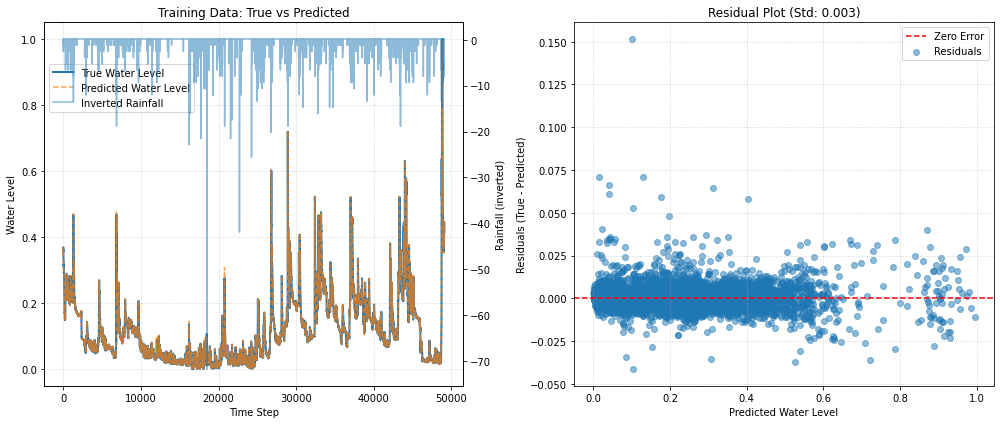

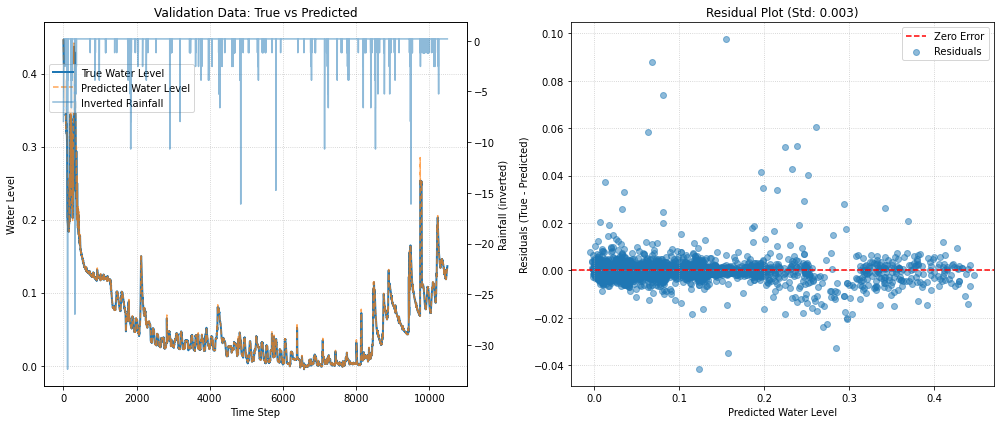

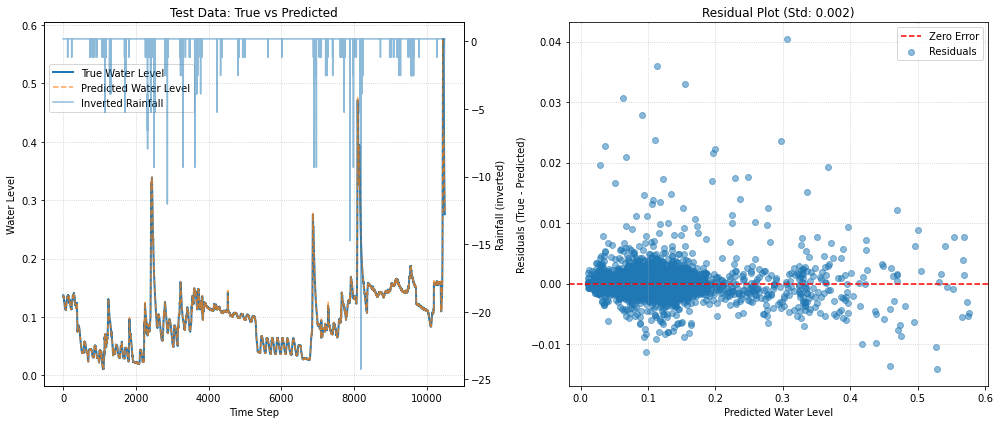

In [28]:
plot_predictions_with_error(y_train, train_pred, rainfall_train, 'Training Data: True vs Predicted')
plot_predictions_with_error(y_val, validation_pred, rainfall_val, 'Validation Data: True vs Predicted')
plot_predictions_with_error(y_test, test_pred, rainfall_test, 'Test Data: True vs Predicted')

In [29]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.999
RMSE: 0.002
MAE: 0.001


# Univariate
Input(X): rainfall <br>
Output(Y): water level

In [30]:
scaler_rain = MinMaxScaler()
rain_scaled = scaler_rain.fit_transform(merged[['Rainfall']])  # only rainfall

# target (water level) in original scale or scaled separately
scaler_level = MinMaxScaler()
level_scaled = scaler_level.fit_transform(merged[['WaterLevel']])

# Combine into one array with rainfall as input and water level as output
# Handle separately in create_sequences
rain_scaled = rain_scaled.reshape(-1)    # flatten to 1D
level_scaled = level_scaled.reshape(-1)  # flatten to 1D

In [31]:
# Train/Validation/Test split
train_size = int(len(rain_scaled) * 0.7)
val_size   = int(len(rain_scaled) * 0.15)
test_size  = len(rain_scaled) - train_size - val_size

rain_train = rain_scaled[:train_size]
level_train = level_scaled[:train_size]

rain_val = rain_scaled[train_size:train_size+val_size]
level_val = level_scaled[train_size:train_size+val_size]

rain_test = rain_scaled[train_size+val_size:]
level_test = level_scaled[train_size+val_size:]

In [32]:
# Create sequences
def create_sequences_univariate(input_series, target_series, past_steps=32, forecast_horizon=1):
    X, y = [], []
    for i in range(len(input_series) - past_steps - forecast_horizon + 1):
        X.append(input_series[i : i + past_steps])  # past rainfall only
        y.append(target_series[i + past_steps : i + past_steps + forecast_horizon][-1])  # future water level
    return np.array(X), np.array(y)

past_steps = 32  # based on lag analysis (≈8 hours)
forecast_horizon = 1

X_train, y_train = create_sequences_univariate(rain_train, level_train, past_steps, forecast_horizon)
X_val, y_val = create_sequences_univariate(rain_val, level_val, past_steps, forecast_horizon)
X_test, y_test = create_sequences_univariate(rain_test, level_test, past_steps, forecast_horizon)

# Reshape X for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (49091, 32, 1) (49091,)
Val: (10494, 32, 1) (10494,)
Test: (10495, 32, 1) (10495,)


In [33]:
model_uni = Sequential()
model_uni.add(LSTM(64, input_shape=(past_steps, 1)))  # 1 feature now
model_uni.add(Dense(1))
model_uni.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history_uni = model_uni.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
768/768 [==============================] - 76s 67ms/step - loss: 0.0083 - val_loss: 0.0049
Epoch 2/200
768/768 [==============================] - 44s 58ms/step - loss: 0.0079 - val_loss: 0.0055
Epoch 3/200
768/768 [==============================] - 44s 58ms/step - loss: 0.0079 - val_loss: 0.0064
Epoch 4/200
768/768 [==============================] - 46s 59ms/step - loss: 0.0079 - val_loss: 0.0068
Epoch 5/200
768/768 [==============================] - 46s 59ms/step - loss: 0.0078 - val_loss: 0.0074
Epoch 6/200
768/768 [==============================] - 43s 56ms/step - loss: 0.0077 - val_loss: 0.0077
Epoch 7/200
768/768 [==============================] - 48s 63ms/step - loss: 0.0077 - val_loss: 0.0063
Epoch 8/200
768/768 [==============================] - 44s 57ms/step - loss: 0.0077 - val_loss: 0.0061
Epoch 9/200
768/768 [==============================] - 46s 60ms/step - loss: 0.0076 - val_loss: 0.0062
Epoch 10/200
768/768 [==============================] - 49s 64ms/step - l

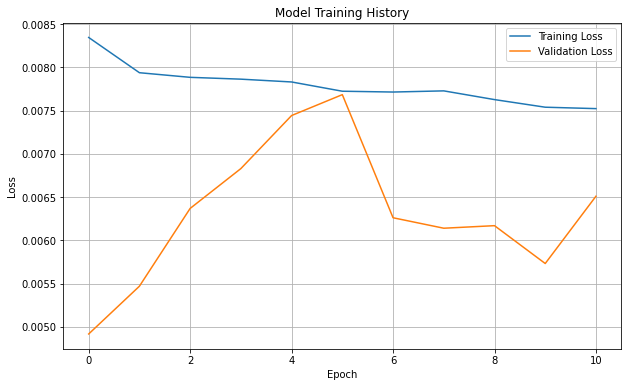

In [37]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_uni.history['loss'], label='Training Loss')
plt.plot(history_uni.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
y_pred_scaled = model_uni.predict(X_test)

# inverse-transform predictions
y_pred = scaler_level.inverse_transform(y_pred_scaled)
y_true = scaler_level.inverse_transform(y_test.reshape(-1,1))

328/328 [==============================] - 8s 13ms/step


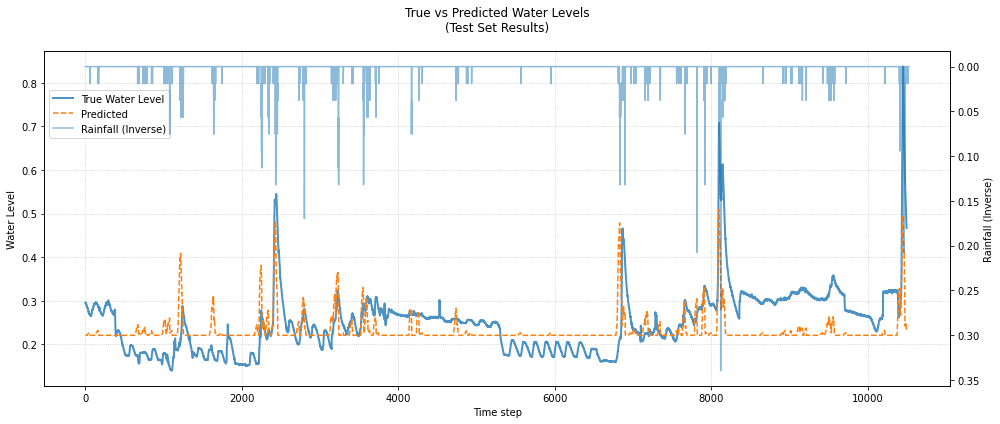

In [35]:
# Inverse-transform predictions and true values
y_pred = scaler_level.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_level.inverse_transform(y_test.reshape(-1, 1)).flatten()

rain_test_reshaped = rain_test.reshape(-1, 1)

# Plot settings
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(y_true, label='True Water Level', color='#1f77b4', linewidth=2, alpha=0.8)
ax1.plot(y_pred, label='Predicted', color='#ff7f0e', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Water Level')
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(rain_test_reshaped, label='Rainfall (Inverse)', color='tab:blue', alpha=0.5)
ax2.set_ylabel('Rainfall (Inverse)')
ax2.invert_yaxis()  # invert y-axis for rainfall

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=10, loc='upper left', bbox_to_anchor=(0, 0.9))

plt.title('True vs Predicted Water Levels\n(Test Set Results)', pad=20)
plt.tight_layout()

In [36]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.127
RMSE: 0.067
MAE: 0.052
